In [37]:
# ============================
# IMPORTS
# ============================

from utils import separer_train_test_par_echantillon, afficher_matrice_confusion, afficher_classification_report
from knn import k_voisins_proches, validation_croisee_knn
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from data_loader import charger_donnees
import numpy as np
import matplotlib.pyplot as plt
from kmeans import kmeans, evaluer_clustering, mapper_clusters_vers_classes
from vote_majoritaire import validation_croisee_complete, VoteMajoritaire
from collections import Counter

# Analyse comparative des méthodes de classification et de clustering

Ce notebook présente une étude visuelle et analytique de différentes méthodes appliquées à un jeu de données d'images.  
Les méthodes analysées incluent :

- **K-Nearest Neighbors (KNN)**
- **K-Means**
- **Vote majoritaire** combinant plusieurs descripteurs

Chaque méthode est évaluée à l'aide de splits fixes ou de validations croisées.  
Les résultats sont visualisés à l'aide de graphiques matplotlib (`pyplot`) pour permettre une interprétation intuitive des performances et des comportements des modèles.  

# Impact du paramètre k sur la précision – Méthode SA

Cette section explore l'effet du choix du paramètre **k** sur les performances de l'algorithme **K-Nearest Neighbors (KNN)**.  

## Visualisation

Le graphique ci-dessous montre :

- L'évolution de la **précision moyenne** en fonction de **k**.
- L'**écart type** pour chaque valeur de k, représenté par des barres d'erreur.
- L'objectif est d'identifier la valeur de **k** qui maximise la précision tout en maintenant une stabilité acceptable.

Lecture terminée.
Nombre total d'images : 99
Fold 1/5 – Accuracy : 68.42%
Fold 2/5 – Accuracy : 63.16%
Fold 3/5 – Accuracy : 73.68%
Fold 4/5 – Accuracy : 68.42%
Fold 5/5 – Accuracy : 68.42%
k=1 → Moyenne : 68.42% ± 3.33%
Accuracies par fold : ['68.42%', '63.16%', '73.68%', '68.42%', '68.42%']
Fold 1/5 – Accuracy : 57.89%
Fold 2/5 – Accuracy : 47.37%
Fold 3/5 – Accuracy : 47.37%
Fold 4/5 – Accuracy : 57.89%
Fold 5/5 – Accuracy : 68.42%
k=3 → Moyenne : 55.79% ± 7.88%
Accuracies par fold : ['57.89%', '47.37%', '47.37%', '57.89%', '68.42%']
Fold 1/5 – Accuracy : 47.37%
Fold 2/5 – Accuracy : 57.89%
Fold 3/5 – Accuracy : 63.16%
Fold 4/5 – Accuracy : 52.63%
Fold 5/5 – Accuracy : 47.37%
k=5 → Moyenne : 53.68% ± 6.14%
Accuracies par fold : ['47.37%', '57.89%', '63.16%', '52.63%', '47.37%']
Fold 1/5 – Accuracy : 36.84%
Fold 2/5 – Accuracy : 31.58%
Fold 3/5 – Accuracy : 63.16%
Fold 4/5 – Accuracy : 78.95%
Fold 5/5 – Accuracy : 63.16%
k=7 → Moyenne : 54.74% ± 17.80%
Accuracies par fold : ['36.84%'

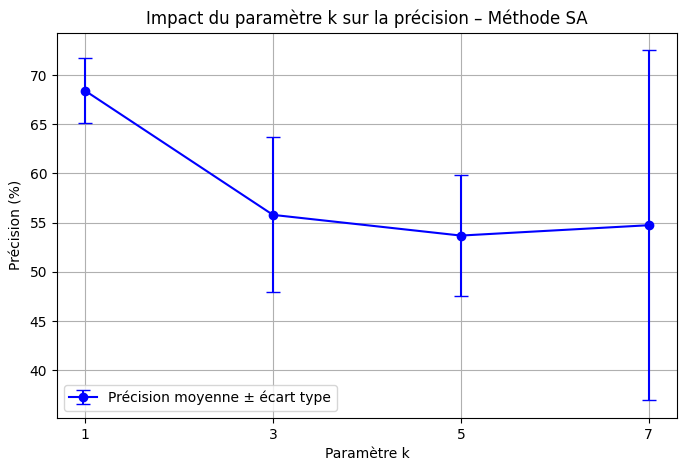

In [38]:
# ============================
# CONFIGURATION
# ============================

np.random.seed(42)  # reproductibilité
base_folder = "./data"
classes = range(1, 10)  # s01 à s09
samples = range(1, 12)  # n001 à n011
methods = ["E34", "GFD", "SA", "F0", "F2"]

# ============================
# CHARGEMENT DES DONNÉES
# ============================
data = charger_donnees(base_folder, classes, samples, methods)
print("Lecture terminée.")
print("Nombre total d'images :", len(data))

# ============================
# IMPACT DU PARAMETRE K SUR LA PRECISION (Méthode SA)
# ============================
method = "SA"
X = [data[key][method] for key in data if method in data[key]]
y = [data[key]["class"] for key in data if method in data[key]]

k_values = [1, 3, 5, 7]
mean_accuracies = []
std_accuracies = []

for k in k_values:
    mean_acc, std_acc, accs = validation_croisee_knn(X, y, k=k, n_folds=5)
    mean_accuracies.append(mean_acc)
    std_accuracies.append(std_acc)
    print(f"k={k} → Moyenne : {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")
    print(f"Accuracies par fold : {[f'{a*100:.2f}%' for a in accs]}")

# ============================
# PLOT
# ============================
plt.figure(figsize=(8,5))
plt.errorbar(k_values, np.array(mean_accuracies)*100, yerr=np.array(std_accuracies)*100, 
             fmt='-o', capsize=5, color='blue', label='Précision moyenne ± écart type')
plt.xticks(k_values)
plt.xlabel("Paramètre k")
plt.ylabel("Précision (%)")
plt.title("Impact du paramètre k sur la précision – Méthode "+ method)
plt.grid(True)
plt.legend()
plt.show()


# Comparaison des descripteurs – KNN
Le graphique suivant montre la précision moyenne obtenue pour chaque descripteur, permettant de comparer leur efficacité relative pour la tâche de classification.

Fold 1/5 – Accuracy : 52.63%
Fold 2/5 – Accuracy : 68.42%
Fold 3/5 – Accuracy : 47.37%
Fold 4/5 – Accuracy : 52.63%
Fold 5/5 – Accuracy : 68.42%
Méthode E34 → Moyenne : 57.89% ± 8.81%
Fold 1/5 – Accuracy : 100.00%
Fold 2/5 – Accuracy : 94.74%
Fold 3/5 – Accuracy : 94.74%
Fold 4/5 – Accuracy : 100.00%
Fold 5/5 – Accuracy : 100.00%
Méthode GFD → Moyenne : 97.89% ± 2.58%
Fold 1/5 – Accuracy : 68.42%
Fold 2/5 – Accuracy : 57.89%
Fold 3/5 – Accuracy : 52.63%
Fold 4/5 – Accuracy : 84.21%
Fold 5/5 – Accuracy : 42.11%
Méthode SA → Moyenne : 61.05% ± 14.36%
Fold 1/5 – Accuracy : 84.21%
Fold 2/5 – Accuracy : 63.16%
Fold 3/5 – Accuracy : 68.42%
Fold 4/5 – Accuracy : 68.42%
Fold 5/5 – Accuracy : 73.68%
Méthode F0 → Moyenne : 71.58% ± 7.14%
Fold 1/5 – Accuracy : 57.89%
Fold 2/5 – Accuracy : 36.84%
Fold 3/5 – Accuracy : 78.95%
Fold 4/5 – Accuracy : 42.11%
Fold 5/5 – Accuracy : 57.89%
Méthode F2 → Moyenne : 54.74% ± 14.74%


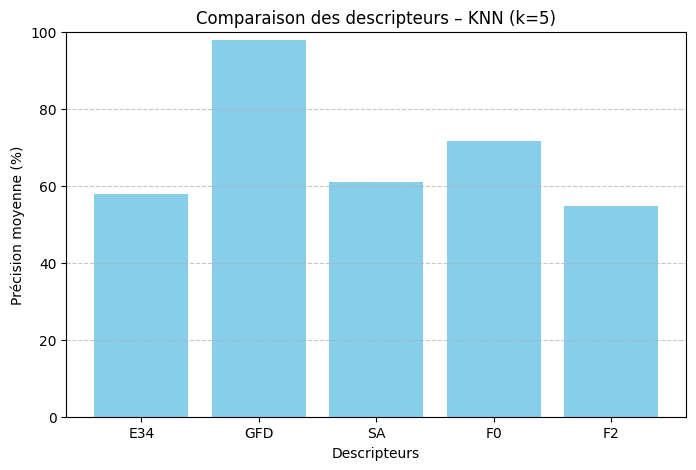

In [39]:
# ============================
# COMPARAISON DE LA PRÉCISION DES DESCRIPTEURS
# ============================
k = 5
mean_accuracies_desc = []

for method in methods:
    X = [data[key][method] for key in data if method in data[key]]
    y = [data[key]["class"] for key in data if method in data[key]]
    
    mean_acc, std_acc, accs = validation_croisee_knn(X, y, k=k, n_folds=5)
    mean_accuracies_desc.append(mean_acc)
    print(f"Méthode {method} → Moyenne : {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")

# ============================
# PLOT
# ============================
plt.figure(figsize=(8,5))
plt.bar(methods, np.array(mean_accuracies_desc)*100, color='skyblue')
plt.xlabel("Descripteurs")
plt.ylabel("Précision moyenne (%)")
plt.title(f"Comparaison des descripteurs – KNN (k={k})")
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Courbe de stabilité

Le graphique montre la précision obtenue pour chaque fold, permettant d'évaluer la stabilité et la variabilité des performances de la méthode.

Fold 1/5 – Accuracy : 63.16%
Fold 2/5 – Accuracy : 73.68%
Fold 3/5 – Accuracy : 57.89%
Fold 4/5 – Accuracy : 68.42%
Fold 5/5 – Accuracy : 68.42%
Méthode SA, k=3 → Moyenne : 66.32% ± 5.37%
Accuracies par fold : ['63.16%', '73.68%', '57.89%', '68.42%', '68.42%']


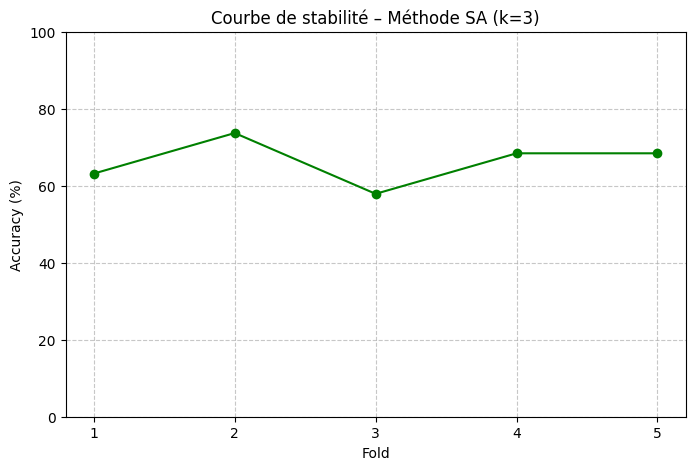

In [40]:
# ===================
# COURBE DE STABILITÉ
# ===================
method = "SA"
k = 3

X = [data[key][method] for key in data if method in data[key]]
y = [data[key]["class"] for key in data if method in data[key]]

# Validation croisée
mean_acc, std_acc, accs = validation_croisee_knn(X, y, k=k, n_folds=5)

# Affichage des résultats
print(f"Méthode {method}, k={k} → Moyenne : {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")
print(f"Accuracies par fold : {[f'{a*100:.2f}%' for a in accs]}")

# ============================
# PLOT
# ============================
plt.figure(figsize=(8,5))
plt.plot(range(1, len(accs)+1), np.array(accs)*100, '-o', color='green')
plt.xticks(range(1, len(accs)+1))
plt.xlabel("Fold")
plt.ylabel("Accuracy (%)")
plt.title(f"Courbe de stabilité – Méthode {method} (k={k})")
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# Matrice de confusion - KNN

Le graphique illustre la distribution des prédictions par rapport aux classes réelles, permettant d’identifier les classes correctement classées et celles problématiques.

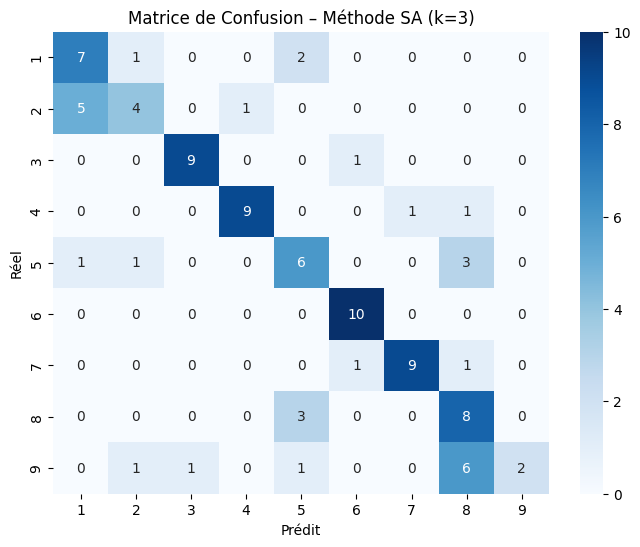

In [41]:
# ============================
# MATRICE DE CONFUSION – Méthode SA, k=3
# ============================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from knn import predire_knn

method = "SA"
k = 3
n_folds = 5
classes_list = list(range(1, 10))  # classes 1 à 9

# Préparer les données
X = [data[key][method] for key in data if method in data[key]]
y = [data[key]["class"] for key in data if method in data[key]]

indices = np.arange(len(X))
np.random.shuffle(indices)
fold_size = len(indices) // n_folds

y_true_all = []
y_pred_all = []

for i in range(n_folds):
    test_idx = indices[i*fold_size : (i+1)*fold_size]
    train_idx = np.setdiff1d(indices, test_idx)

    X_train = [X[j] for j in train_idx]
    y_train = [y[j] for j in train_idx]
    X_test  = [X[j] for j in test_idx]
    y_test  = [y[j] for j in test_idx]

    # Prédictions
    y_pred = [predire_knn(X_train, y_train, x, k) for x in X_test]

    # Stocker pour la matrice de confusion globale
    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

# ====================
# MATRICE DE CONFUSION
# ====================
cm = confusion_matrix(y_true_all, y_pred_all, labels=classes_list)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes_list, yticklabels=classes_list)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title(f"Matrice de Confusion – Méthode {method} (k={k})")
plt.show()


# Courbe Précision-Rappel

Le graphique montre le compromis **précision / rappel** pour chaque classe, utile pour évaluer les classes difficiles et comparer la performance globale du classificateur.

Échantillons de test : [2, 5, 8]
Accuracy : 100.00%

Matrice de Confusion :

KNN – Matrice de Confusion (GFD) :

          1     2     3     4     5     6     7     8     9 | Total
-------------------------------------------------------------------
  1 |     3     0     0     0     0     0     0     0     0 | 3
  2 |     0     3     0     0     0     0     0     0     0 | 3
  3 |     0     0     3     0     0     0     0     0     0 | 3
  4 |     0     0     0     3     0     0     0     0     0 | 3
  5 |     0     0     0     0     3     0     0     0     0 | 3
  6 |     0     0     0     0     0     3     0     0     0 | 3
  7 |     0     0     0     0     0     0     3     0     0 | 3
  8 |     0     0     0     0     0     0     0     3     0 | 3
  9 |     0     0     0     0     0     0     0     0     3 | 3
-------------------------------------------------------------------
Tot |     3     3     3     3     3     3     3     3     3 | 27

Rapport de classification :
             

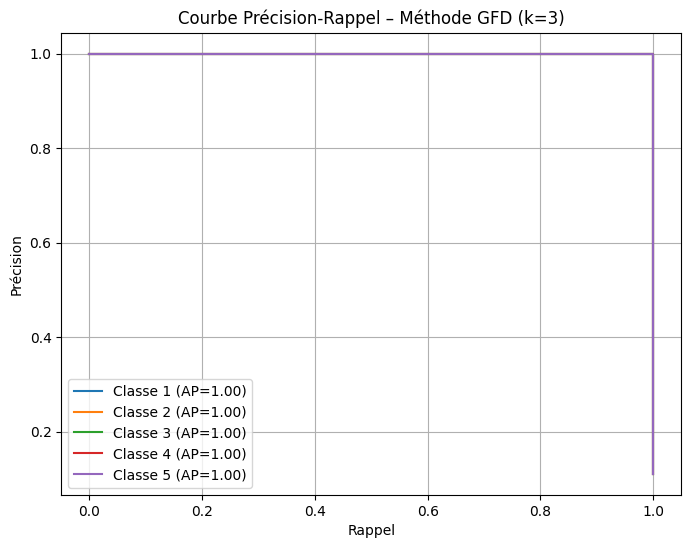

In [42]:
# ============================
# COURBE PRECISION - RAPPEL
# ============================

echantillons_test = [2, 5, 8]
method = "GFD"
k = 3

# Séparer train/test
X_train, y_train, X_test, y_test = separer_train_test_par_echantillon(data, echantillons_test, method)
print(f"Échantillons de test : {echantillons_test}")

# Prédiction
y_pred = [predire_knn(X_train, y_train, x, k=k) for x in X_test]

# Affichage accuracy
accuracy = np.mean(np.array(y_pred) == np.array(y_test))
print(f"Accuracy : {accuracy*100:.2f}%\n")

# Matrice de confusion
print("Matrice de Confusion :")
afficher_matrice_confusion(y_test, y_pred, classes, titre=f"KNN – Matrice de Confusion ({method})")

# Rapport classification
print("\nRapport de classification :")
afficher_classification_report(y_test, y_pred, classes)

# Binarisation des labels
classes_list = list(classes)
y_true_bin = label_binarize(y_test, classes=classes_list)

# Création des scores par classe (votes des k voisins)
y_scores = []
for x in X_test:
    voisins = k_voisins_proches(X_train, y_train, x, k)
    votes = [voisins.count(cls) for cls in classes_list]  # nombre de votes par classe
    y_scores.append(votes)

y_scores = np.array(y_scores)

# Tracer la PR curve pour chaque classe
plt.figure(figsize=(8,6))
for i, cls in enumerate(classes_list[:5]):
    precision, recall, _ = precision_recall_curve(y_true_bin[:,i], y_scores[:,i])
    ap = average_precision_score(y_true_bin[:,i], y_scores[:,i])
    plt.plot(recall, precision, label=f"Classe {cls} (AP={ap:.2f})")

plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.title(f"Courbe Précision-Rappel – Méthode {method} (k={k})")
plt.legend()
plt.grid(True)
plt.show()

# Taux d’erreur par classe

Cette section présente le **taux d’erreur par classe**. Elle permet d’identifier quelles classes sont les plus difficiles à classifier et de compléter l’analyse des performances globales.

Classe 1 : 0.00% d'erreur
Classe 2 : 33.33% d'erreur
Classe 3 : 0.00% d'erreur
Classe 4 : 0.00% d'erreur
Classe 5 : 33.33% d'erreur
Classe 6 : 0.00% d'erreur
Classe 7 : 0.00% d'erreur
Classe 8 : 33.33% d'erreur
Classe 9 : 100.00% d'erreur


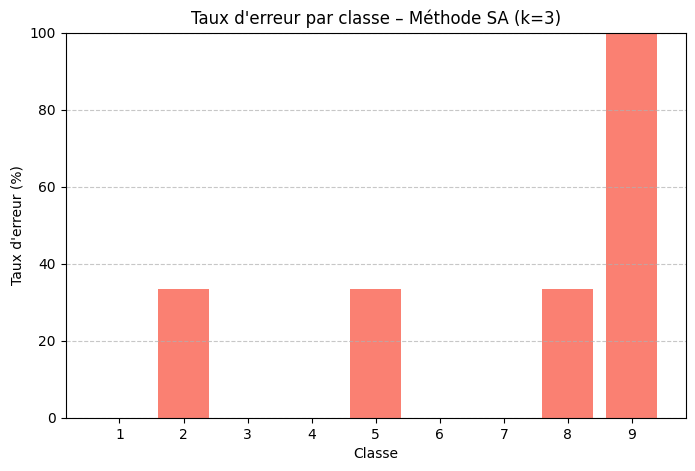

In [43]:
# ============================
# TAUX D'ERREUR PAR CLASSE (SPLIT FIXE)
# ============================

echantillons_test = [2, 5, 8]
method = "SA"
k = 3

# Séparer train/test
X_train, y_train, X_test, y_test = separer_train_test_par_echantillon(data, echantillons_test, method)

# Prédictions
y_pred = [predire_knn(X_train, y_train, x, k=k) for x in X_test]

# Calcul du taux d'erreur par classe
classes_list = list(classes)
taux_erreur = []

for cls in classes_list:
    indices = [i for i, label in enumerate(y_test) if label == cls]
    if len(indices) == 0:
        taux_erreur.append(0)
        continue
    erreurs = sum(y_pred[i] != y_test[i] for i in indices)
    taux_erreur.append(erreurs / len(indices))

# Optionnel : afficher les valeurs exactes
for cls, te in zip(classes_list, taux_erreur):
    print(f"Classe {cls} : {te*100:.2f}% d'erreur")

# Affichage
plt.figure(figsize=(8,5))
plt.bar(classes_list, np.array(taux_erreur)*100, color='salmon')
plt.xlabel("Classe")
plt.ylabel("Taux d'erreur (%)")
plt.title(f"Taux d'erreur par classe – Méthode {method} (k={k})")
plt.xticks(classes_list)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Précision (%) selon le paramètre k – Tous descripteurs

Cette section analyse comment le **paramètre k** influence la précision du KNN pour chaque descripteur.  
L'objectif est de comparer la performance de chaque descripteur selon différentes valeurs de k et d’identifier la valeur optimale pour chaque méthode.

Fold 1/5 – Accuracy : 47.37%
Fold 2/5 – Accuracy : 52.63%
Fold 3/5 – Accuracy : 78.95%
Fold 4/5 – Accuracy : 73.68%
Fold 5/5 – Accuracy : 78.95%
Méthode E34, k=1 → Moyenne : 66.32% ± 13.56%
Fold 1/5 – Accuracy : 73.68%
Fold 2/5 – Accuracy : 73.68%
Fold 3/5 – Accuracy : 52.63%
Fold 4/5 – Accuracy : 57.89%
Fold 5/5 – Accuracy : 47.37%
Méthode E34, k=3 → Moyenne : 61.05% ± 10.84%
Fold 1/5 – Accuracy : 52.63%
Fold 2/5 – Accuracy : 47.37%
Fold 3/5 – Accuracy : 84.21%
Fold 4/5 – Accuracy : 63.16%
Fold 5/5 – Accuracy : 52.63%
Méthode E34, k=5 → Moyenne : 60.00% ± 13.15%
Fold 1/5 – Accuracy : 73.68%
Fold 2/5 – Accuracy : 68.42%
Fold 3/5 – Accuracy : 57.89%
Fold 4/5 – Accuracy : 63.16%
Fold 5/5 – Accuracy : 36.84%
Méthode E34, k=7 → Moyenne : 60.00% ± 12.72%
Fold 1/5 – Accuracy : 94.74%
Fold 2/5 – Accuracy : 100.00%
Fold 3/5 – Accuracy : 100.00%
Fold 4/5 – Accuracy : 100.00%
Fold 5/5 – Accuracy : 100.00%
Méthode GFD, k=1 → Moyenne : 98.95% ± 2.11%
Fold 1/5 – Accuracy : 100.00%
Fold 2/5 – Accura

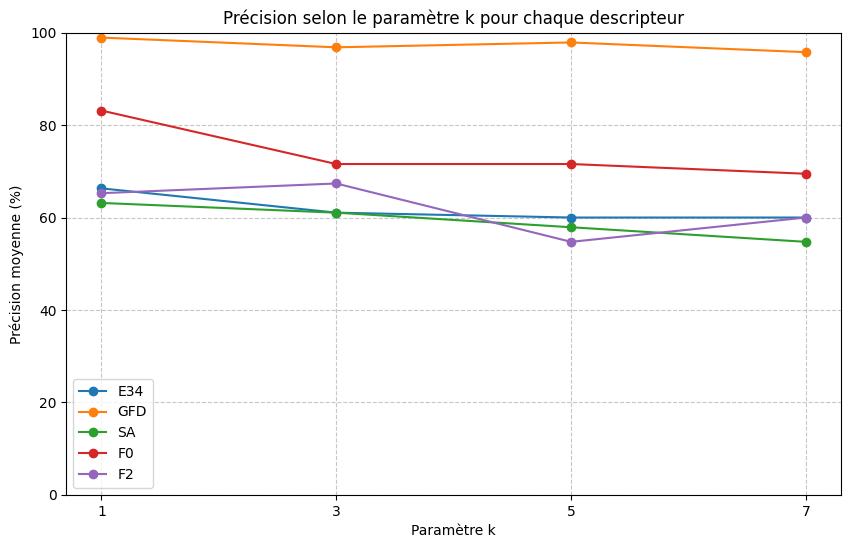

In [44]:
# ============================
# PRECISION (%) SELON LA METHODE K (Tous descripteurs)
# ============================

k_values = [1, 3, 5, 7]
methods_list = ["E34", "GFD", "SA", "F0", "F2"]

# Stocker les précisions moyennes
precision_moyenne = {method: [] for method in methods_list}

for method in methods_list:
    X = [data[key][method] for key in data if method in data[key]]
    y = [data[key]["class"] for key in data if method in data[key]]
    
    for k in k_values:
        mean_acc, std_acc, accs = validation_croisee_knn(X, y, k=k, n_folds=5)
        precision_moyenne[method].append(mean_acc*100)
        print(f"Méthode {method}, k={k} → Moyenne : {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")

# ============================
# PLOT
# ============================
plt.figure(figsize=(10,6))
for method in methods_list:
    plt.plot(k_values, precision_moyenne[method], '-o', label=method)

plt.xticks(k_values)
plt.xlabel("Paramètre k")
plt.ylabel("Précision moyenne (%)")
plt.title("Précision selon le paramètre k pour chaque descripteur")
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


# Inertie et Pureté vs Nombre de Clusters - K-MEANS

Cette section explore l’effet du **nombre de clusters (k)** sur la qualité du clustering K-Means pour le descripteur **SA**.  
Deux métriques sont étudiées :

- **Inertie** : somme des distances au carré entre les points et le centre de leur cluster (plus faible = meilleur regroupement).  
- **Pureté (%)** : mesure de la cohérence entre les clusters et les classes réelles (plus élevé = meilleure correspondance).

- **Nombre de clusters testé** : de 2 à 11  
- **Algorithme K-Means** : `kmeans++` pour l’initialisation, 10 répétitions, 100 itérations max.

## Visualisation

Le graphique montre simultanément l’évolution de l’inertie et de la pureté en fonction de k :

- Axe gauche (bleu) : Inertie  
- Axe droit (vert) : Pureté (%)  

Cette représentation permet d’identifier le **nombre optimal de clusters** où l’inertie commence à se stabiliser et où la pureté reste élevée.

k=2 → Inertie: 0.20, Pureté: 14.14%
k=3 → Inertie: 0.17, Pureté: 15.15%
k=4 → Inertie: 0.14, Pureté: 23.23%
k=5 → Inertie: 0.12, Pureté: 33.33%
k=6 → Inertie: 0.11, Pureté: 25.25%
k=7 → Inertie: 0.09, Pureté: 33.33%
k=8 → Inertie: 0.08, Pureté: 39.39%
k=9 → Inertie: 0.07, Pureté: 38.38%
k=10 → Inertie: 0.08, Pureté: 48.48%
k=11 → Inertie: 0.06, Pureté: 39.39%


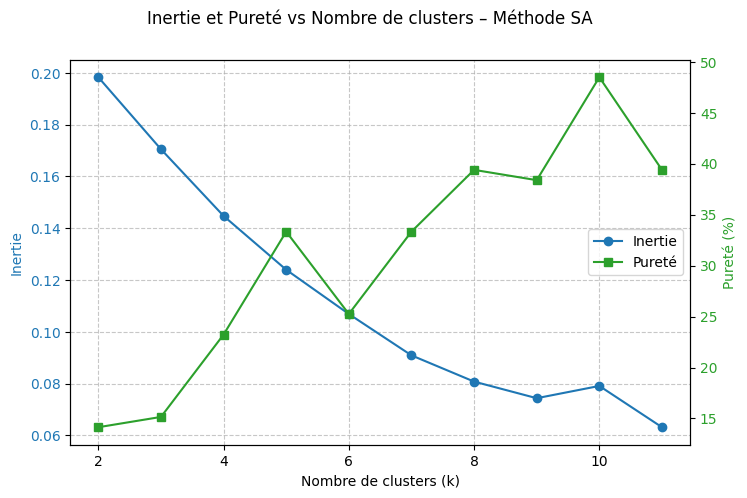

In [46]:
# ============================
# INERTIE & PURETE vs NOMBRE DE CLUSTERS – Méthode SA
# ============================

method = "SA"
X = np.array([data[key][method] for key in data if method in data[key]])
y_true = np.array([data[key]["class"] for key in data if method in data[key]])

k_values = range(2, 12)  # Nombre de clusters à tester
inerties = []
puretes = []

for k in k_values:
    y_pred, centroids, inertia = kmeans(X, k=k, max_iter=100, init='kmeans++', n_init=10)
    purity = evaluer_clustering(y_true, y_pred)
    inerties.append(inertia)
    puretes.append(purity*100)
    print(f"k={k} → Inertie: {inertia:.2f}, Pureté: {purity*100:.2f}%")

# ============================
# PLOT DOUBLE
# ============================
fig, ax1 = plt.subplots(figsize=(8,5))

color1 = 'tab:blue'
ax1.set_xlabel("Nombre de clusters (k)")
ax1.set_ylabel("Inertie", color=color1)
ax1.plot(k_values, inerties, '-o', color=color1, label='Inertie')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()  # second axe Y
color2 = 'tab:green'
ax2.set_ylabel("Pureté (%)", color=color2)
ax2.plot(k_values, puretes, '-s', color=color2, label='Pureté')
ax2.tick_params(axis='y', labelcolor=color2)

fig.suptitle(f"Inertie et Pureté vs Nombre de clusters – Méthode {method}")
ax1.grid(True, linestyle='--', alpha=0.7)

# Légendes combinées
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='center right')

plt.show()


# Matrice de Confusion – K-MEANS

Le graphique illustre la distribution des prédictions par rapport aux classes réelles, permettant d’identifier les classes correctement classées et celles problématiques.


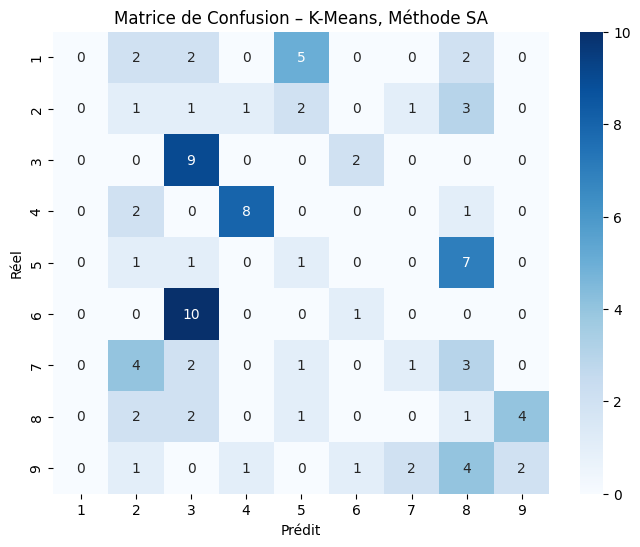

In [ ]:
# ============================
# MATRICE DE CONFUSION – K-MEANS, Méthode SA
# ============================

method = "SA"
k_clusters = 9
n_folds = 5
classes_list = list(range(1, 10))  # classes 1 à 9

# Préparer les données
X = np.array([data[key][method] for key in data if method in data[key]])
y = np.array([data[key]["class"] for key in data if method in data[key]])

indices = np.arange(len(X))
np.random.shuffle(indices)
fold_size = len(indices) // n_folds

y_true_all = []
y_pred_all = []

for i in range(n_folds):
    test_idx = indices[i*fold_size : (i+1)*fold_size]
    train_idx = np.setdiff1d(indices, test_idx)

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Appliquer K-Means sur le fold d'entraînement
    y_train_pred, centroids, _ = kmeans(X_train, k=k_clusters, max_iter=100, init='kmeans++', n_init=10)

    # Mapper clusters vers classes
    _, mapping = mapper_clusters_vers_classes(y_train_pred, y_train)

    # Prédiction sur le fold test
    y_test_pred = []
    for x in X_test:
        dists = [np.linalg.norm(x - c) for c in centroids]
        cluster = np.argmin(dists)
        y_test_pred.append(mapping.get(cluster, -1))  # sécurité

    y_true_all.extend(y_test)
    y_pred_all.extend(y_test_pred)

# Affichage de la matrice de confusion
cm = confusion_matrix(y_true_all, y_pred_all, labels=classes_list)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes_list, yticklabels=classes_list)
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.title(f"Matrice de Confusion – K-Means, Méthode {method}")
plt.show()

# Stabilité du K-MEANS

L’objectif est de mesurer la **sensibilité de K-Means aux conditions initiales**. Une faible variance indique que l’algorithme est stable pour ce descripteur et ce nombre de clusters.
Cela permet de visualiser à la fois la performance moyenne et la variabilité du clustering.


Test de stabilité sur 20 initialisations aléatoires...


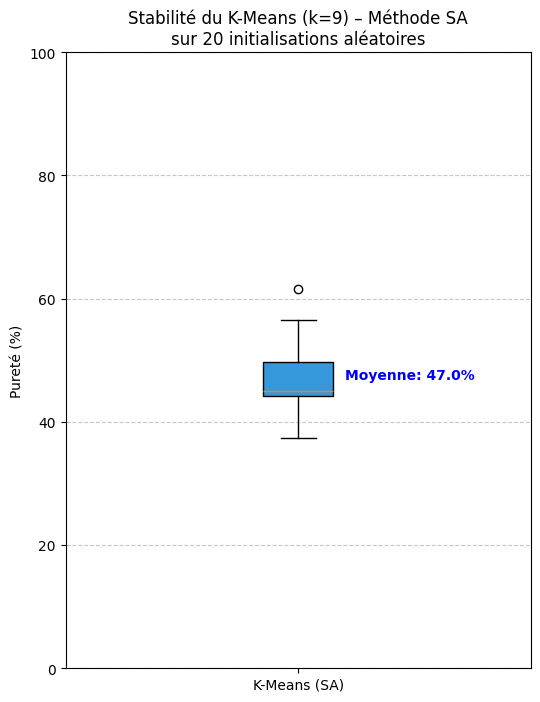

In [ ]:
# ============================
# STABILITÉ DU K-MEANS – Méthode SA, k=9
# ============================
method = "SA"
k_clusters = 9
n_runs = 20

# Préparer les données
X = np.array([data[key][method] for key in data if method in data[key]])
y_true = np.array([data[key]["class"] for key in data if method in data[key]])

# Vérification simple
if len(X) == 0:
    raise ValueError(f"Aucune donnée trouvée pour la méthode {method}")
if k_clusters > len(X):
    raise ValueError(f"Nombre de clusters k={k_clusters} supérieur au nombre d'échantillons={len(X)}")

purities = []

print(f"Test de stabilité sur {n_runs} initialisations aléatoires...")

for i in range(n_runs):
    y_pred, _, _ = kmeans(X, k=k_clusters, max_iter=100, init='random', n_init=1)
    purity, _ = evaluer_clustering(y_true, y_pred)
    purities.append(purity * 100)

# ============================
# PLOT
# ============================
plt.figure(figsize=(6, 8))
plt.boxplot(purities, patch_artist=True, boxprops=dict(facecolor="#3498db"))
plt.ylabel('Pureté (%)')
plt.title(f'Stabilité du K-Means (k={k_clusters}) – Méthode {method}\nsur {n_runs} initialisations aléatoires')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Afficher la moyenne
plt.text(1.1, np.mean(purities), f'Moyenne: {np.mean(purities):.1f}%', 
         color='blue', fontweight='bold')

plt.xticks([1], [f'K-Means ({method})'])
plt.ylim(0, 100)
plt.show()


# Équilibre des clusters

Cette section compare la **taille des clusters générés par K-Means** avec la **répartition réelle des classes**.
Cela permet d’évaluer visuellement l’équilibre des clusters par rapport à la distribution réelle.

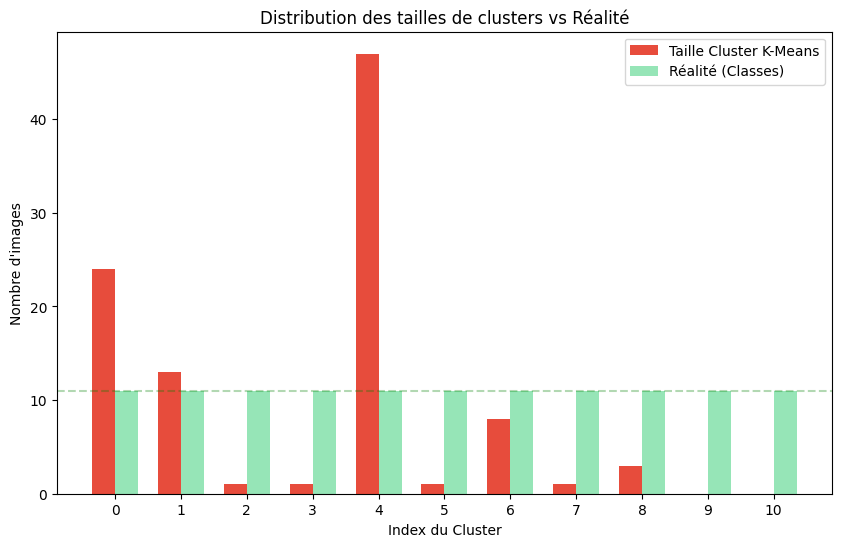

In [ ]:
# ============================
# ÉQUILIBRE DES CLUSTERS – Méthode GFD, k=9
# ============================
method = "SA"
k_clusters = 9

X = np.array([d[method] for d in data.values() if method in d])

# On lance K-Means
y_pred, _, _ = kmeans(X, k=k_clusters, max_iter=100, init='kmeans++', n_init=10)

# Comptage
counts = Counter(y_pred)
cluster_sizes = [counts[i] for i in range(k)]

# Attendu (11 images par classe pour 9 classes)
expected = [11] * k

x = np.arange(k)
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, cluster_sizes, width, label='Taille Cluster K-Means', color='#e74c3c')
plt.bar(x + width/2, expected, width, label='Réalité (Classes)', color='#2ecc71', alpha=0.5)

plt.xlabel('Index du Cluster')
plt.ylabel("Nombre d'images")
plt.title('Distribution des tailles de clusters vs Réalité')
plt.xticks(x)
plt.legend()
plt.axhline(y=11, color='green', linestyle='--', alpha=0.3)
plt.show()


# Comparaison Supervisé vs Non-Supervisé par Descripteur

Cette section présente une **comparaison des performances** entre un classifieur **supervisé (KNN)** et un algorithme **non-supervisé (K-Means)** pour chaque descripteur utilisé dans notre dataset.  

- **Descripteurs évalués** : E34, GFD, SA, F0, F2  
- **KNN** : k = 3, validation croisée 5-fold  
- **K-Means** : k = 9 clusters, 20 initialisations aléatoires (`kmeans++`)  

L’objectif est d’évaluer **l’écart de précision** entre un modèle supervisé qui utilise les classes réelles et un modèle non-supervisé qui tente de regrouper les données sans information de classe.


Fold 1/5 – Accuracy : 68.42%
Fold 2/5 – Accuracy : 63.16%
Fold 3/5 – Accuracy : 68.42%
Fold 4/5 – Accuracy : 57.89%
Fold 5/5 – Accuracy : 68.42%
Fold 1/5 – Accuracy : 100.00%
Fold 2/5 – Accuracy : 100.00%
Fold 3/5 – Accuracy : 84.21%
Fold 4/5 – Accuracy : 94.74%
Fold 5/5 – Accuracy : 100.00%
Fold 1/5 – Accuracy : 73.68%
Fold 2/5 – Accuracy : 57.89%
Fold 3/5 – Accuracy : 78.95%
Fold 4/5 – Accuracy : 52.63%
Fold 5/5 – Accuracy : 57.89%
Fold 1/5 – Accuracy : 63.16%
Fold 2/5 – Accuracy : 68.42%
Fold 3/5 – Accuracy : 78.95%
Fold 4/5 – Accuracy : 57.89%
Fold 5/5 – Accuracy : 89.47%
Fold 1/5 – Accuracy : 63.16%
Fold 2/5 – Accuracy : 63.16%
Fold 3/5 – Accuracy : 68.42%
Fold 4/5 – Accuracy : 52.63%
Fold 5/5 – Accuracy : 57.89%


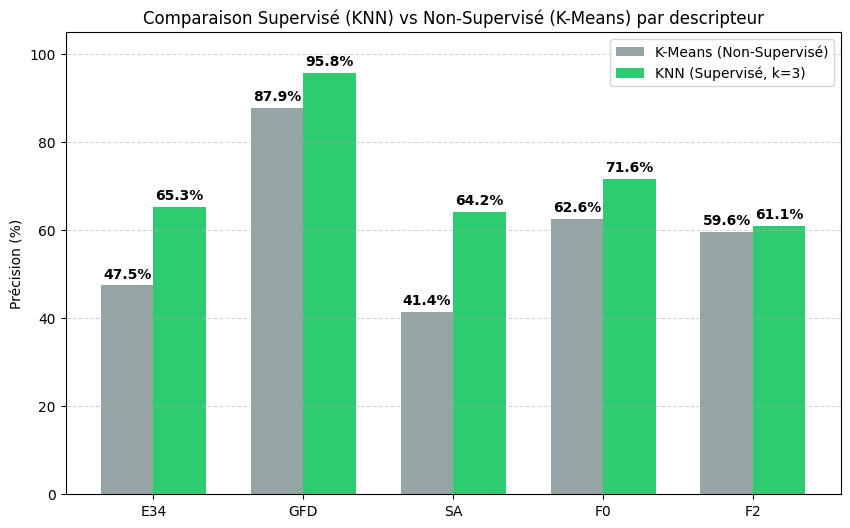

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Descripteurs
methods = ["E34", "GFD", "SA", "F0", "F2"]

# Valeurs pour KNN et K-Means
k_knn = 3
k_kmeans = 9

acc_knn_all = []
acc_kmeans_all = []

for method in methods:
    # --- KNN ---
    X = np.array([d[method] for d in data.values() if method in d])
    y_true = np.array([d["class"] for d in data.values() if method in d])
    mean_acc_knn, _, _ = validation_croisee_knn(X, y_true, k=k_knn, n_folds=5)
    acc_knn_all.append(mean_acc_knn * 100)

    # --- K-Means ---
    y_pred, _, _ = kmeans(X, k=k_kmeans, max_iter=100, init='kmeans++', n_init=20)
    y_mapped, _ = mapper_clusters_vers_classes(y_pred, y_true)
    acc_kmeans = np.sum(y_mapped == y_true) / len(y_true) * 100
    acc_kmeans_all.append(acc_kmeans)

# ============================
# PLOT
# ============================
x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(10,6))
bars1 = plt.bar(x - width/2, acc_kmeans_all, width, label='K-Means (Non-Supervisé)', color='#95a5a6')
bars2 = plt.bar(x + width/2, acc_knn_all, width, label=f'KNN (Supervisé, k={k_knn})', color='#2ecc71')

plt.xticks(x, methods)
plt.ylabel('Précision (%)')
plt.ylim(0, 105)
plt.title('Comparaison Supervisé (KNN) vs Non-Supervisé (K-Means) par descripteur')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Afficher les valeurs au-dessus des barres
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                 f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()

# Vote Majoritaire : Comparaison des stratégies

Cette section compare les performances obtenues par le meilleur classifieur individuel (KNN avec GFD) aux performances des différentes stratégies d'apprentissage par ensemble (vote majoritaire).

L'objectif est d'évaluer si la combinaison des descripteurs, même les moins performants, apporte un gain de robustesse et de précision globale.

Calcul des performances en cours...

FOLD 1/3
Échantillons de test : [10, 5, 7]
Taille du test : 27 échantillons

Performances individuelles:
  E34: 74.07%
  GFD: 100.00%
  SA : 70.37%
  F0 : 77.78%
  F2 : 59.26%

Performances du vote majoritaire:
  majoritaire_simple  : 100.00%
  majoritaire_pondere : 100.00%
  majoritaire_confiance: 100.00%

FOLD 2/3
Échantillons de test : [11, 8, 2]
Taille du test : 27 échantillons

Performances individuelles:
  E34: 77.78%
  GFD: 100.00%
  SA : 74.07%
  F0 : 70.37%
  F2 : 66.67%

Performances du vote majoritaire:
  majoritaire_simple  : 100.00%
  majoritaire_pondere : 100.00%
  majoritaire_confiance: 100.00%

FOLD 3/3
Échantillons de test : [6, 9, 1, 4, 3]
Taille du test : 45 échantillons

Performances individuelles:
  E34: 62.22%
  GFD: 93.33%
  SA : 44.44%
  F0 : 75.56%
  F2 : 53.33%

Performances du vote majoritaire:
  majoritaire_simple  : 86.67%
  majoritaire_pondere : 91.11%
  majoritaire_confiance: 93.33%

RÉSUMÉ DE LA VALIDATION CROISÉE

Mo

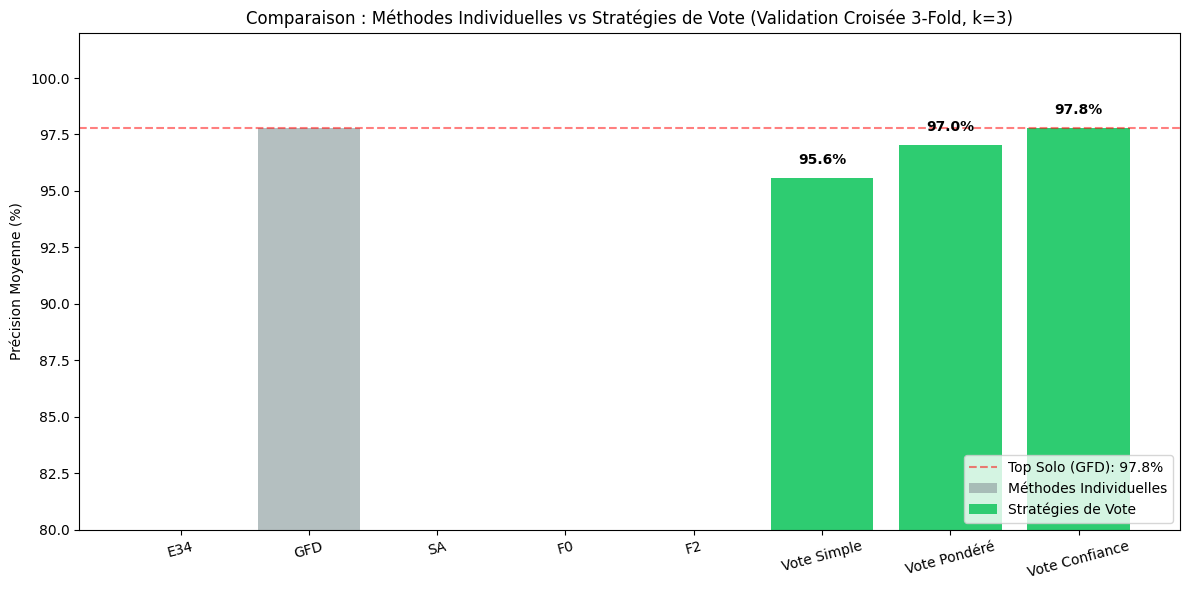

In [ ]:
k=3 # Paramètre k du KNN utilisé dans le vote
n_classes=len(classes) 
n_folds=3 

print("Calcul des performances en cours...")
res = validation_croisee_complete(data, k=k, n_folds=n_folds, n_classes=n_classes)

# Préparation des données pour le graphique
methods = list(res['resultats_individuels'].keys())
# Extraction de la précision moyenne des méthodes individuelles
acc_methods = [np.mean(res['resultats_individuels'][m])*100 for m in methods] 
modes = ['majoritaire_simple', 'majoritaire_pondere', 'majoritaire_confiance']
# Extraction de la précision moyenne des modes de vote
acc_modes = [np.mean(res['resultats_par_mode'][m])*100 for m in modes]
labels_modes = ['Vote Simple', 'Vote Pondéré', 'Vote Confiance']

# Graphique
plt.figure(figsize=(12, 6))

# Barres pour les méthodes seules (Gris/Bleu)
plt.bar(methods, acc_methods, color='#95a5a6', label='Méthodes Individuelles', alpha=0.7)

# Barres pour les votes (Vert)
x_modes = np.arange(len(methods), len(methods) + len(modes))
bars_vote = plt.bar(x_modes, acc_modes, color='#2ecc71', label='Stratégies de Vote')
# Ligne pour la meilleure méthode individuelle
best_single = max(acc_methods)
plt.axhline(y=best_single, color='red', linestyle='--', alpha=0.5, label=f'Top Solo (GFD): {best_single:.1f}%')

# Annotations
plt.xticks(list(range(len(methods))) + list(x_modes), methods + labels_modes, rotation=15)
plt.ylabel('Précision Moyenne (%)')
plt.title('Comparaison : Méthodes Individuelles vs Stratégies de Vote (Validation Croisée 3-Fold, k=3)')
plt.ylim(80, 102) # Zoom pour voir les différences
plt.legend(loc='lower right')

# Ajouter les valeurs sur les votes
for bar in bars_vote:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
    
plt.tight_layout()
plt.show()

# Matrice de Confusion du Meilleur Modèle (9 Classes)

Pour analyser la robustesse du mode de vote optimal (`majoritaire_confiance`), cette matrice permet d'identifier les classes qui restent difficiles à distinguer, même avec l'approche par ensemble, et de confirmer les gains de rappel sur les classes problématiques.

Calcul des prédictions (k=3, 3 folds) en cours...

FOLD 1/3
Échantillons de test : [8, 5, 6]
Taille du test : 27 échantillons

Performances individuelles:
  E34: 62.96%
  GFD: 100.00%
  SA : 70.37%
  F0 : 74.07%
  F2 : 62.96%

Performances du vote majoritaire:
  majoritaire_simple  : 96.30%
  majoritaire_pondere : 100.00%
  majoritaire_confiance: 96.30%

FOLD 2/3
Échantillons de test : [1, 2, 7]
Taille du test : 27 échantillons

Performances individuelles:
  E34: 62.96%
  GFD: 96.30%
  SA : 66.67%
  F0 : 77.78%
  F2 : 55.56%

Performances du vote majoritaire:
  majoritaire_simple  : 88.89%
  majoritaire_pondere : 92.59%
  majoritaire_confiance: 92.59%

FOLD 3/3
Échantillons de test : [10, 3, 4, 9, 11]
Taille du test : 45 échantillons

Performances individuelles:
  E34: 55.56%
  GFD: 97.78%
  SA : 55.56%
  F0 : 66.67%
  F2 : 55.56%

Performances du vote majoritaire:
  majoritaire_simple  : 84.44%
  majoritaire_pondere : 95.56%
  majoritaire_confiance: 97.78%

RÉSUMÉ DE LA VALIDATION CRO

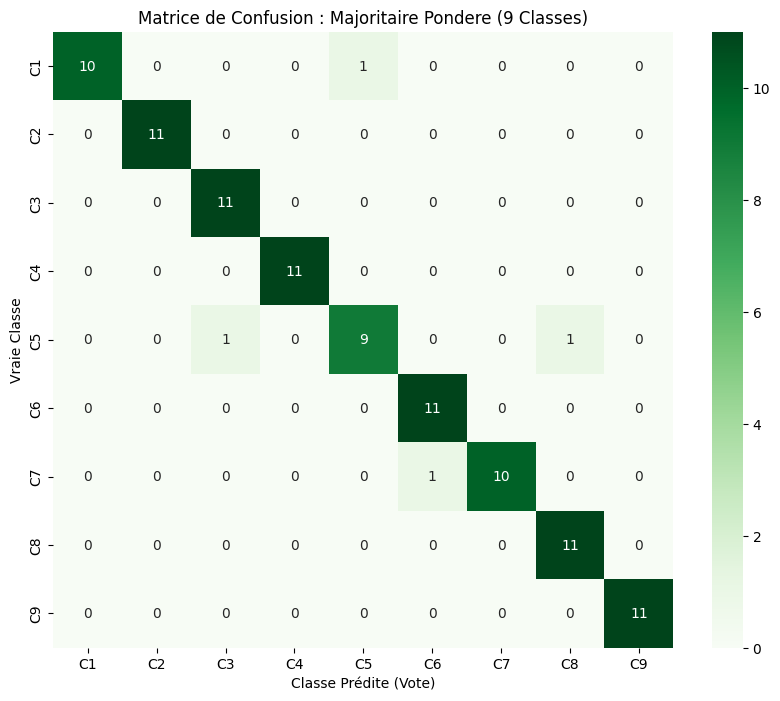

In [ ]:
from sklearn.metrics import confusion_matrix

k = 3

# Récupération des résultats globaux de la validation croisée (recalcule si nécessaire)
print(f"Calcul des prédictions (k={k}, 3 folds) en cours...")
res = validation_croisee_complete(data, k=k, n_folds=3, n_classes=9)

# Récupération du mode de vote optimal et des prédictions/vraies classes associées
best_mode = res['best_mode']
y_true = res['all_y_true'][best_mode]
y_pred = res['all_y_pred'][best_mode]

# Calcul de la Matrice de Confusion à partir des listes agrégées
classes_list = list(range(1, n_classes + 1))
cm = confusion_matrix(np.array(y_true), np.array(y_pred), labels=classes_list)

# Affichage avec Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=[f"C{i}" for i in classes_list],
            yticklabels=[f"C{i}" for i in classes_list])

plt.xlabel('Classe Prédite (Vote)')
plt.ylabel('Vraie Classe')
plt.title(f'Matrice de Confusion : {best_mode.replace("_", " ").title()} (9 Classes)')
plt.show()

# Analyse de l'Amélioration par Classe : GFD vs Vote Majoritaire (Confiance)

Ce graphique illustre l'apport qualitatif du vote majoritaire (`majoritaire_confiance`) par rapport au meilleur descripteur individuel (`GFD`) sur la métrique critique du **Rappel (Sensibilité)**. Le Rappel mesure la capacité du modèle à identifier correctement les échantillons de chaque classe. Les annotations montrent le gain (en points de pourcentage) apporté par le vote.

Recalcul des performances (k=3, 3 folds) pour l'analyse des rappels...

FOLD 1/3
Échantillons de test : [11, 3, 2]
Taille du test : 27 échantillons

Performances individuelles:
  E34: 70.37%
  GFD: 100.00%
  SA : 59.26%
  F0 : 77.78%
  F2 : 66.67%

Performances du vote majoritaire:
  majoritaire_simple  : 92.59%
  majoritaire_pondere : 96.30%
  majoritaire_confiance: 100.00%

FOLD 2/3
Échantillons de test : [4, 1, 5]
Taille du test : 27 échantillons

Performances individuelles:
  E34: 59.26%
  GFD: 96.30%
  SA : 62.96%
  F0 : 92.59%
  F2 : 70.37%

Performances du vote majoritaire:
  majoritaire_simple  : 92.59%
  majoritaire_pondere : 92.59%
  majoritaire_confiance: 92.59%

FOLD 3/3
Échantillons de test : [10, 7, 8, 9, 6]
Taille du test : 45 échantillons

Performances individuelles:
  E34: 53.33%
  GFD: 100.00%
  SA : 60.00%
  F0 : 73.33%
  F2 : 48.89%

Performances du vote majoritaire:
  majoritaire_simple  : 91.11%
  majoritaire_pondere : 93.33%
  majoritaire_confiance: 93.33%

RÉSUM

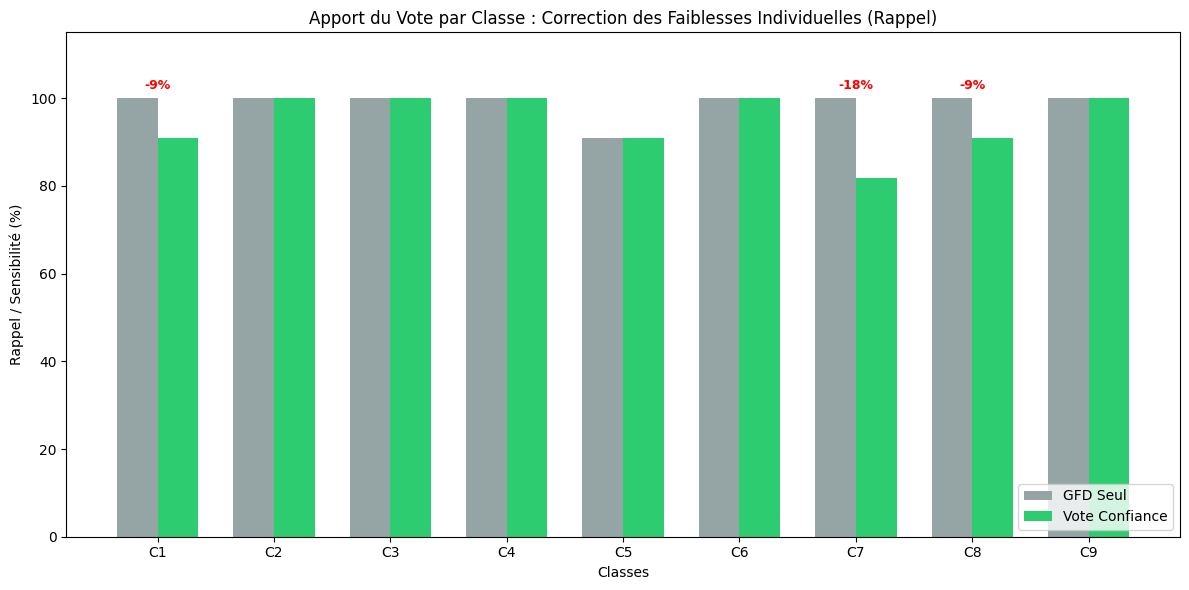

In [ ]:
from sklearn.metrics import recall_score

# DÉFINITION D'UNE FONCTION UTILITAIRE POUR LE CALCUL DES RAPPELS PAR CLASSE
def calculer_metriques_detaillees(y_true, y_pred):
    """Calcule le Rappel par classe et retourne le résultat dans une structure de dictionnaire."""
    classes_list = list(range(1, 10)) # Classes 1 à 9
    recalls = recall_score(y_true, y_pred, labels=classes_list, average=None, zero_division=0)
    
    metriques = {}
    for i, c in enumerate(classes_list):
        metriques[c] = {'rappel': recalls[i]}
    return metriques


k = 3
n_classes = len(classes) 

# Récupération des résultats globaux de la validation croisée (recalcule pour la robustesse)
print(f"Recalcul des performances (k={k}, 3 folds) pour l'analyse des rappels...")
# 'data' et 'validation_croisee_complete' sont supposés être définis/importés dans les cellules précédentes
res = validation_croisee_complete(data, k=k, n_folds=3, n_classes=n_classes)

# Calcul des métriques par classe
# 1. Pour GFD seul
metriques_gfd = calculer_metriques_detaillees(
    res['all_y_true_ind']['GFD'], 
    res['all_y_pred_ind']['GFD'])
rappels_gfd = [metriques_gfd[c]['rappel']*100 for c in range(1, n_classes + 1)]

# 2. Pour le Vote (Confiance)
metriques_vote = calculer_metriques_detaillees(
    res['all_y_true']['majoritaire_confiance'], 
    res['all_y_pred']['majoritaire_confiance'])
rappels_vote = [metriques_vote[c]['rappel']*100 for c in range(1, n_classes + 1)]

# Graphique
x = np.arange(1, n_classes + 1)
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(x - width/2, rappels_gfd, width, label='GFD Seul', color='#95a5a6')
bars_vote = plt.bar(x + width/2, rappels_vote, width, label='Vote Confiance', color='#2ecc71')

plt.xlabel('Classes')
plt.ylabel('Rappel / Sensibilité (%)')
plt.title('Apport du Vote par Classe : Correction des Faiblesses Individuelles (Rappel)')
plt.xticks(x, [f"C{i}" for i in x])
plt.legend(loc='lower right')
plt.ylim(0, 115)

# Flèches de gain
for i in range(n_classes):
    gain = rappels_vote[i] - rappels_gfd[i]
    
    # Position y pour l'annotation
    y_pos = max(rappels_vote[i], rappels_gfd[i])
    
    if abs(gain) > 0.1: # Seulement si gain significatif
        text_color = 'green' if gain > 0 else 'red'
        # Utilisation de x[i] pour centrer l'annotation entre les deux barres
        plt.annotate(f"{'+' if gain > 0 else ''}{gain:.0f}%", 
                     (x[i], y_pos + 2),
                     ha='center', color=text_color, fontweight='bold', fontsize=9)
        
plt.tight_layout()
plt.show()

# Ablation Study : Importance Relative des Descripteurs (Vote par Confiance)

Cette étude par ablation mesure l'impact de chaque descripteur sur la performance du meilleur modèle d'ensemble (`majoritaire_confiance`). Nous utilisons le split fixe (`[2, 5, 8]`) pour ces tests.

L'impact est mesuré par la perte de précision (en %) lorsque la méthode est retirée du vote.
* Une perte positive (barre rouge) signifie que la méthode est **essentielle** (son retrait fait chuter la précision).
* Une perte négative (barre verte) signifie que la méthode est **nuisible ou redondante** (son retrait améliore la performance).

Séparation train/test sur split fixe [2, 5, 8]...
Baseline (Vote Confiance, 5 méthodes) : 100.00%
Calcul de l'impact par retrait (ablation) en cours...


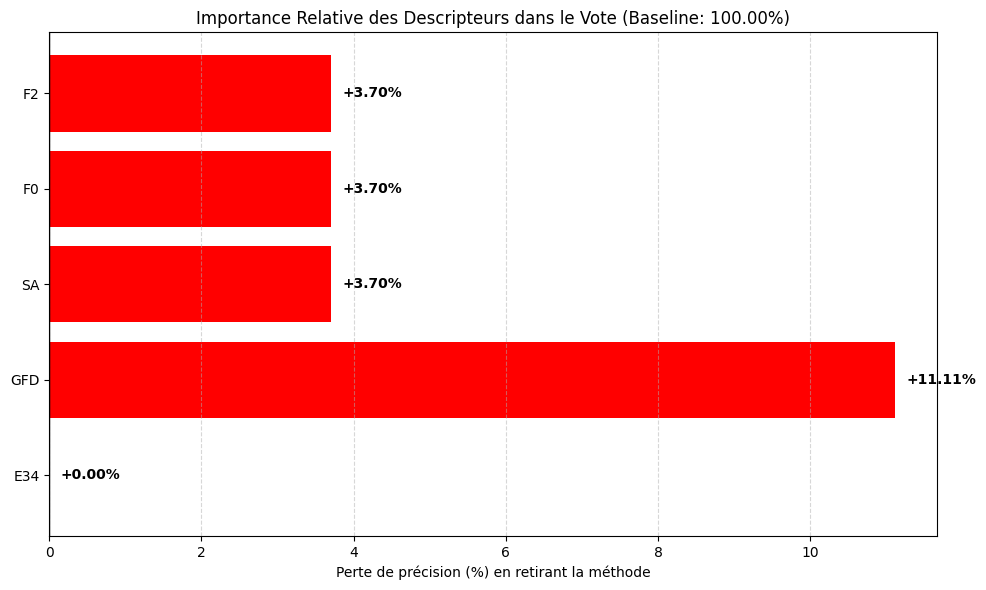

In [ ]:
print("Séparation train/test sur split fixe [2, 5, 8]...")
split = separer_train_test_par_echantillon(data, [2, 5, 8], all_methods=True)

# 1. Baseline (Toutes les méthodes)
voteur = VoteMajoritaire(k=3) # k=3 tel qu'utilisé dans l'analyse d'importance de resultats.txt
voteur.entrainer(split, verbose=False)
pred, _ = voteur.predire_ensemble(split, mode='majoritaire_confiance')
y_test = split['GFD']['y_test'] # La vraie classe est la même pour tous les descripteurs
baseline = np.sum(pred == y_test) / len(y_test) * 100

impacts = []
print(f"Baseline (Vote Confiance, 5 méthodes) : {baseline:.2f}%")
print("Calcul de l'impact par retrait (ablation) en cours...")

for m_exclude in methods:
    # Créer un sous-ensemble sans la méthode m_exclude
    sub_split = {k: v for k, v in split.items() if k != m_exclude}
    
    voteur_sub = VoteMajoritaire(k=3)
    # L'entraînement et la prédiction se font sur le sous-ensemble
    voteur_sub.entrainer(sub_split, verbose=False) 
    pred_sub, _ = voteur_sub.predire_ensemble(sub_split, mode='majoritaire_confiance')
    
    acc_sub = np.sum(pred_sub == y_test) / len(y_test) * 100
    
    # L'impact est la PERTE de précision : baseline - acc_sub
    # Si impact > 0, la méthode était utile.
    impacts.append(baseline - acc_sub)
    
# Graphique
plt.figure(figsize=(10, 6))

# Rouge = méthode essentielle (impact > 0) ; Vert = méthode nuisible ou neutre (impact <= 0)
colors = ['red' if x > 0 else 'green' for x in impacts] 
plt.barh(methods, impacts, color=colors)

plt.axvline(x=0, color='black', linewidth=1)
plt.xlabel('Perte de précision (%) en retirant la méthode')
plt.title(f'Importance Relative des Descripteurs dans le Vote (Baseline: {baseline:.2f}%)')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Annotations
for i, v in enumerate(impacts):
    # Position du texte ajustée pour la lisibilité
    x_pos = v + (0.15 if v >= 0 else -0.15)
    ha_align = 'left' if v >= 0 else 'right'
    plt.text(x_pos, i, f"{v:+.2f}%", 
             ha=ha_align, va='center', fontweight='bold')
    
plt.tight_layout()
plt.show()